Exercise 1— Conceptual Questions

1. Loss Functions
The Discriminator performs a binary classification task (real vs fake), so the appropriate loss function is Binary Cross-Entropy Loss (BCELoss)
We need a minimax objective because the system is adversarial: the Discriminator tries to maximize its ability to distinguish real from fake, while the Generator tries to minimize it by producing realistic samples. If both used the same simple objective independently, there would be no competition, and the Generator would not learn meaningful data distribution

2. The Latent Space
If the same latent vector z is fed into a trained Generator multiple times, it will always produce the same image because the Generator is deterministic
If two latent vectors are very close, the generated outputs will also be similar. This shows that the latent space is continuous and structured, meaning small changes in latent space correspond to smooth changes in output space. This is an important property because it allows interpolation between features

3. Evaluating GANs
GAN evaluation is difficult because there is no ground truth label for “realism” or “diversity”.

Qualitative evaluation:
Human inspection of generated images to judge realism, clarity, and whether digits look visually correct

Quantitative evaluation:
One common metric is Inception Score (IS) or Frechet Inception Distance (FID), which measures both image quality and diversity by comparing generated samples to real data distributions

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
dataloader = DataLoader(mnist, batch_size=64, shuffle=True)

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.35MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 18.8MB/s]


In [3]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

In [5]:
latent_dim = 100
lr = 0.0002
epochs = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator(latent_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optim_G = optim.Adam(G.parameters(), lr=lr)
optim_D = optim.Adam(D.parameters(), lr=lr)

In [ ]:
for epoch in range(epochs):
    for real, _ in dataloader:
        real = real.to(device)
        batch_size = real.size(0)


        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        outputs = D(real)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, latent_dim).to(device)
        fake = G(z)

        outputs = D(fake.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        optim_D.zero_grad()
        d_loss.backward()
        optim_D.step()

        z = torch.randn(batch_size, latent_dim).to(device)
        fake = G(z)

        outputs = D(fake)
        g_loss = criterion(outputs, real_labels)

        optim_G.zero_grad()
        g_loss.backward()
        optim_G.step()

    print(f"Epoch [{epoch+1}/{epochs}]  D_loss: {d_loss.item():.4f}  G_loss: {g_loss.item():.4f}")

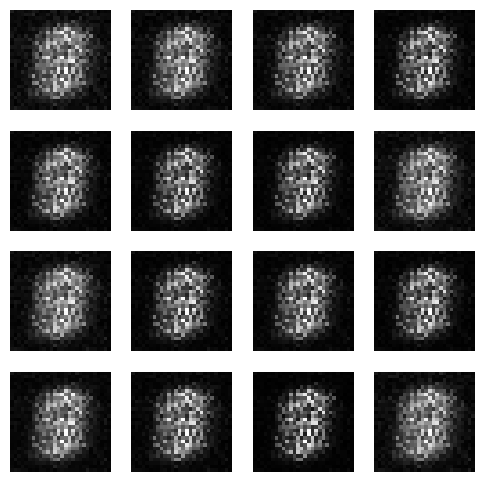

In [7]:
def show_images(images):
    images = images.view(-1, 28, 28).cpu().detach().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6,6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i], cmap="gray")
        ax.axis("off")
    plt.show()


z = torch.randn(16, latent_dim).to(device)
fake_images = G(z)
show_images(fake_images)

Mode Collapse Observation:

Mode collapse happens when the Generator produces only a limited variety of digits, ignoring parts of the data distribution.
This can be observed when outputs become repetitive, for example generating only “1” or “7”.

Why Label Smoothing Helps
Label smoothing makes the Discriminator less confident by replacing hard labels (0 and 1) with soft values (e.g., 0.9 and 0.1)
This prevents the Discriminator from becoming too strong too quickly. If the Discriminator is too perfect, the Generator receives weak gradients and collapses to a few modes
By making the Discriminator slightly uncertain, the Generator receives richer gradient signals, encouraging exploration of the full data distribution and reducing mode collapse